# Khảo sát Tham số Toàn diện (Full Parameter Sweep)
**Mục tiêu:** Trình diễn cách lựa chọn tham số tối ưu (Tuning) cho từng chặng xử lý ảnh, từ việc tẩy lông, cân bằng sáng cho đến phân đoạn và trích xuất đặc trưng Y khoa.

## 0. Nạp công cụ & Dữ liệu

In [1]:
import cv2
import matplotlib.pyplot as plt
import sys
import os

# Đảm bảo import được từ src
sys.path.append(r'd:\Computer Vision Final Project\Src code')

from src.parameter_sweep import sweep_dullrazor, sweep_clahe, sweep_otsu, sweep_kmeans, sweep_snakes, sweep_abcd_compactness

img_path = r'd:\Computer Vision Final Project\Src code\data\train\images\ISIC_0000074.jpg'
gt_path = r'd:\Computer Vision Final Project\Src code\data\train\masks\ISIC_0000074_segmentation.png'

img = cv2.imread(img_path)
img = cv2.resize(img, (600, 450))
gt_mask = cv2.resize(cv2.imread(gt_path, 0), (600, 450))

print("Đã nạp xong ảnh để chuẩn bị khảo sát!")

Đã nạp xong ảnh để chuẩn bị khảo sát!


## 1. Khảo sát Kích thước Chổi Xóa lông (DullRazor)
- **kernel = 5:** Chổi quá nhỏ, chỉ xóa được lông tơ, để lọt lông to đen rậm.
- **kernel = 15:** Vừa vặn, làm sạch lông mà vẫn giữ được ranh giới khối u.
- **kernel = 25:** Quá to, gây nhòe nhoẹt (Blur) mạnh lên các vân da và làm nhòe viền u.

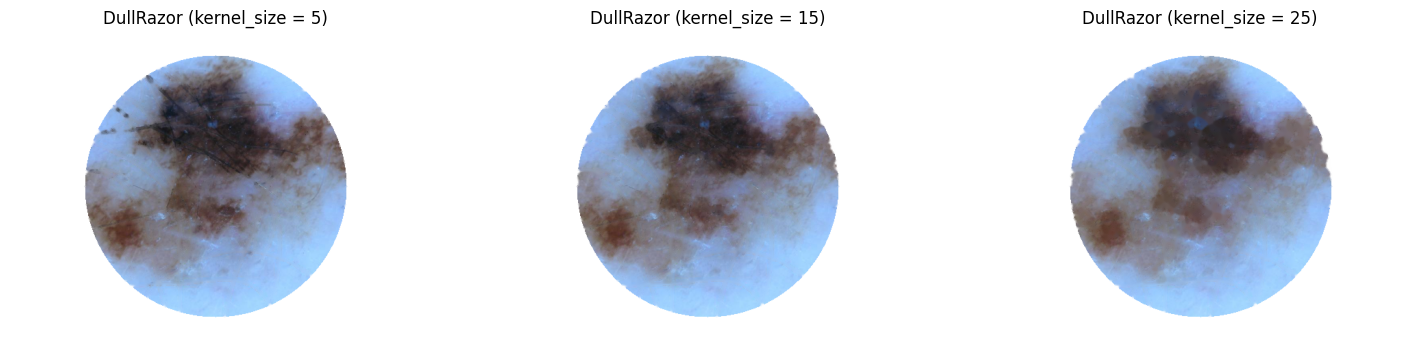

In [2]:
fig = sweep_dullrazor(img)
plt.show()

## 2. Khảo sát Độ gắt Tương phản (CLAHE)
- **clip_limit = 1.0:** Gần như không tăng tương phản, khối u mờ viền sẽ chìm vào da.
- **clip_limit = 1.1:** Tương phản nhẹ nhàng, làm nổi khối u.
- **clip_limit = 3.0:** Tương phản cực gắt, vân da nổi lên cuồn cuộn $\rightarrow$ Thuật toán viền sẽ bám nhầm vào rãnh vân da.

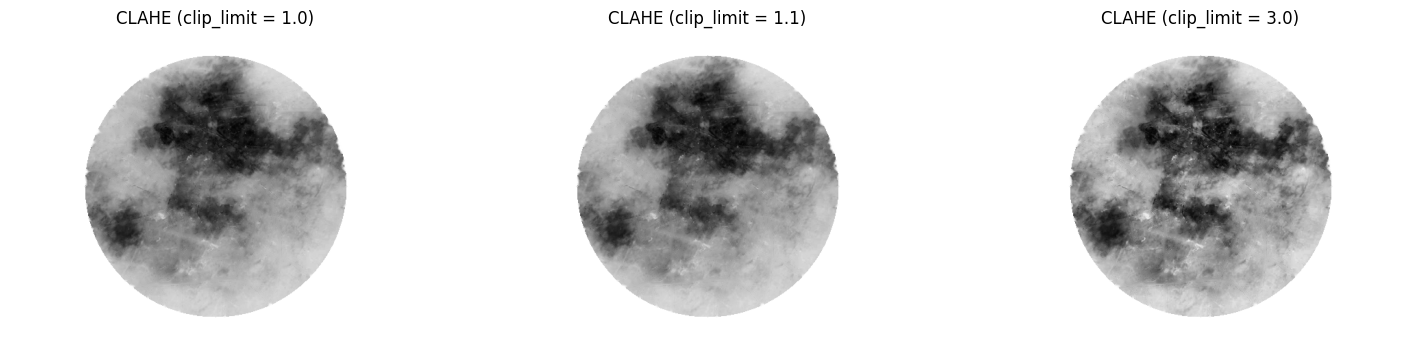

In [3]:
fig = sweep_clahe(img)
plt.show()

## 3. Khảo sát Dọn rác cho Otsu Thresholding
- Trục dọc (Open): Xóa rác trắng bên ngoài khối u. Chổi càng to thì xóa càng sạch rác, nhưng cũng cắn lẹm vào ranh giới khối u thật.
- Trục ngang (Close): Lấp lỗ thủng đen bên trong. Chổi càng to thì lấp lỗ càng tốt nhưng làm khối u trở nên "béo" và tròn trịa sai sự thật.

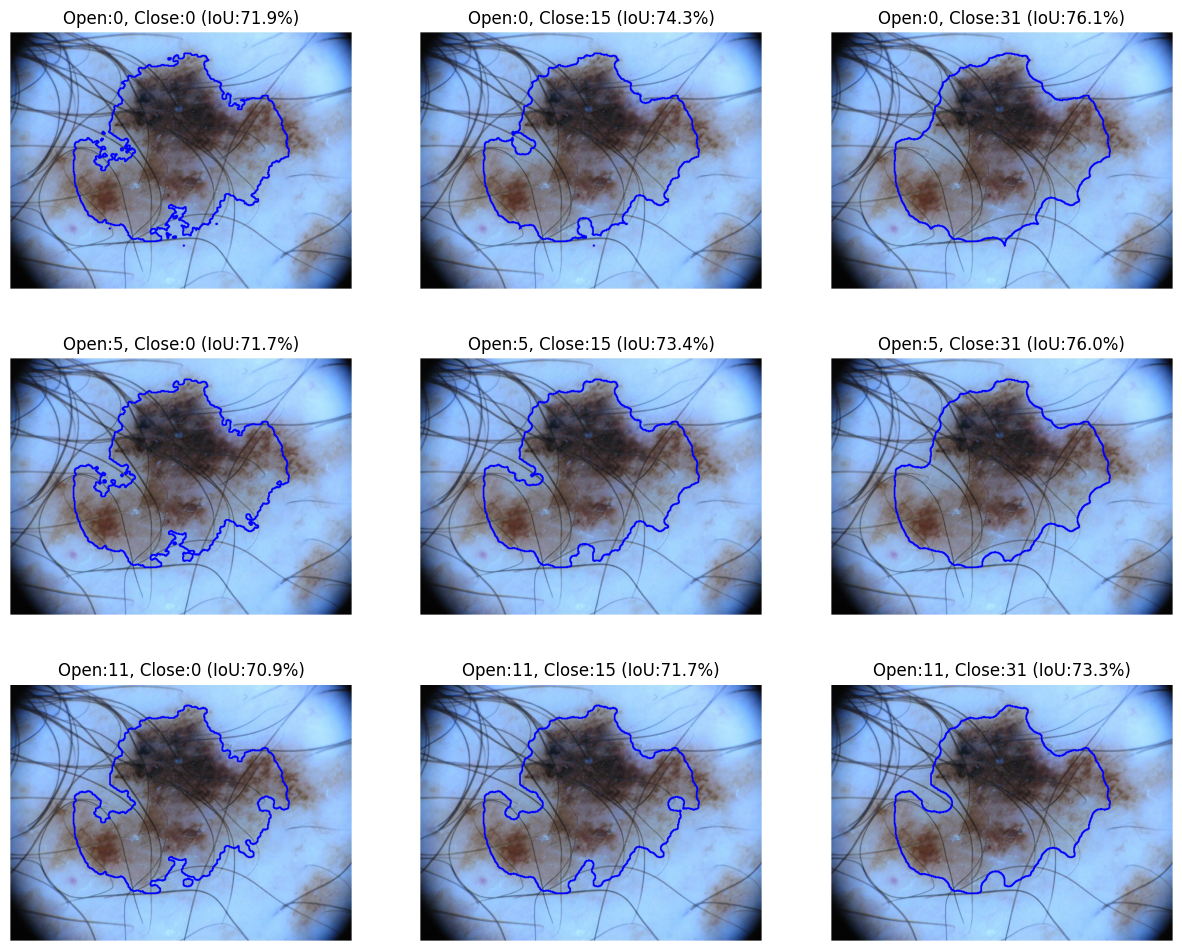

In [4]:
fig = sweep_otsu(img, gt_mask)
plt.show()

## 4. Khảo sát Số lượng cụm màu (K-Means Spatial Prior)
- **K = 2:** Chia Trắng/Đen (Giống Otsu). Dính viền mờ vào da nền (Under-segmentation).
- **K = 4:** Điểm lý tưởng. Thuật toán tự bốc 2 cụm gần tâm nhất, bao trọn Lõi u đậm + Viền mờ nhạt dần.
- **K = 6:** Băm ảnh ra quá vụn, lõi khối u bị vỡ thành nhiều mảnh lốm đốm (Over-segmentation).

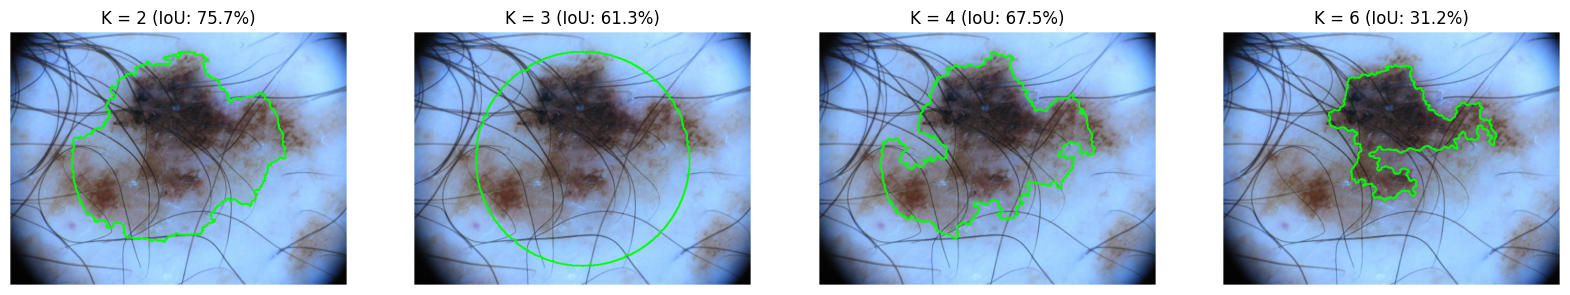

In [5]:
fig = sweep_kmeans(img, gt_mask)
plt.show()

## 5. Khảo sát Số vòng lặp (Morphological Snakes)
- **Iter = 5:** Dây thun nở quá ngắn, đường viền còn cứng nhắc, chưa lách vào hang hốc nham nhở.
- **Iter = 35:** Điểm dừng hoàn hảo. Dây ôm khít.
- **Iter = 100:** Dây thun giãn quá lố, bò ra khỏi khối u và lan sang nếp nhăn của da.

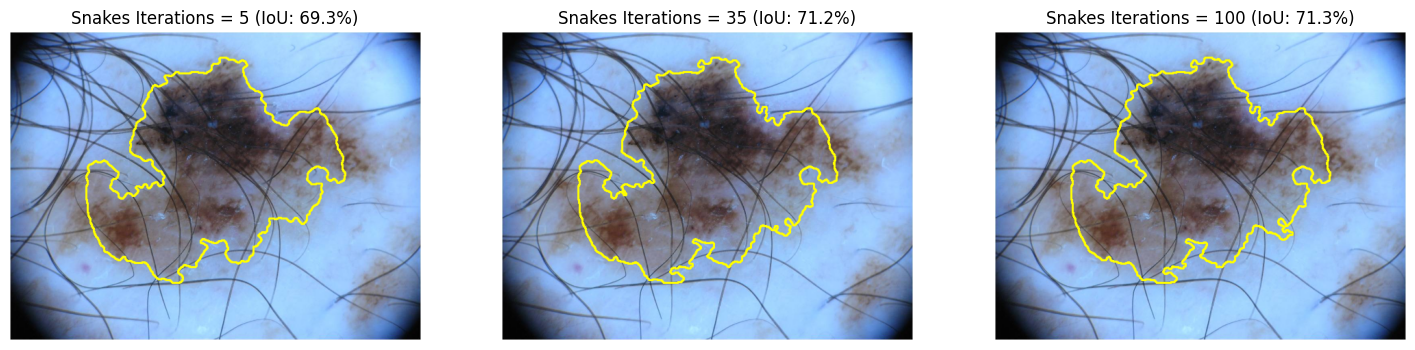

In [6]:
fig = sweep_snakes(img, gt_mask)
plt.show()

## 6. Khảo sát Độ nhạy chấm điểm Y khoa (ABCD - Compactness)
Đặc trưng chữ B (Border) dùng công thức Compactness (Độ nham nhở). Một hình tròn hoàn hảo có Compactness = 1.0. Ở đây ta khảo sát cách hệ số nhạy (multiplier) phóng đại độ nham nhở để chấm ra thang điểm (0-8).

In [7]:
# Dùng mask tối ưu của K-Means để lấy được viền nham nhở nhất
from src.segmentation import get_kmeans_mask
from src.preprocessing import apply_circular_mask, remove_hair, enhance_contrast_clahe

img_no_corners = apply_circular_mask(img, 0.85)
clean_img, _ = remove_hair(img_no_corners, kernel_size=15, inpaint_rad=3)
clahe_color, _ = enhance_contrast_clahe(clean_img, clip_limit=1.1)
clahe_color = apply_circular_mask(clahe_color, 0.85)

optimal_mask = get_kmeans_mask(clahe_color, k=4)

sweep_abcd_compactness(img, optimal_mask)

Hệ số Compactness thực tế của khối u này là: 0.209
-> Nếu dùng hệ số nhạy = 5: Điểm chữ B sẽ là 4/8 điểm.
-> Nếu dùng hệ số nhạy = 20: Điểm chữ B sẽ là 8/8 điểm.
-> Nếu dùng hệ số nhạy = 50: Điểm chữ B sẽ là 8/8 điểm.
